# Lý thuyết về Histogram và KDE

## Phân phối dữ liệu: 
Trong xử lý ảnh số, mỗi bức ảnh được cấu thành từ các pixel mang giá trị cường độ sáng (thường từ 0 đến 255). Việc mô tả phân phối là quá trình thống kê tần suất xuất hiện của các giá trị này giúp xác định:

* **Tính tập trung:** Dữ liệu tập trung ở những khoảng nào.
* **Độ phân tán:** Dữ liệu trải rộng hay thu hẹp.
* **Hình dạng:** Dữ liệu có đối xứng (phân phối chuẩn), lệch trái/phải (skewed), nhiều đỉnh (multimodal).
* **Về mặt thống kê:** Phân phối cho biết đặc điểm dữ liệu ảnh, giúp nhận diện ảnh quá tối (underexposed), quá sáng (overexposed),...
* **Về mặt học máy:** Việc xác định được phân phối pixel có thể giúp chọn ra phương pháp chuẩn hóa (Normalization) phù hợp, nhằm đưa dữ liệu về một khoảng giá trị ổn định, giúp các thuật toán như KNN, Logistic Regression hội tụ nhanh hơn.
## Histogram
**Histogram**: là một kỹ thuật thống kê biểu diễn sự phân phối thực nghiệm của tập dữ liệu liên tục. Trong phần này, dữ liệu là cường độ sáng của các pixel.

<img src="https://d33wubrfki0l68.cloudfront.net/cf5633adbbfd2f4e3c21106adcaa1cacc1f263a1/c5ea1/post/data-visualization/histogram_files/figure-html/unnamed-chunk-1-1.png" width="500">

**Cách xác định**
* **Chia thùng (Binning):** Toàn bộ dải giá trị của pixel (thường là $[0, 255]$) được chia thành $L$ khoảng gọi là bins.
* **Đếm:** Với mỗi pixel có giá trị thuộc về thùng nào và tăng giá trị đếm của thùng đó.

**Ý nghĩa**
* **Xác định phân phối cường độ sáng:** dựa vào biểu đồ có thể xác định vùng tối (lệch trái), vùng sáng (lệch phải) hay vùng trung tính.
* **Đánh giá độ tương phản:** Dải Histogram rộng và trải đều sẽ biểu thị độ tương phản cao. Histogram co cụm sẽ cho biết độ tương phản thấp.
* **Phát hiện hiện tượng "cháy" ảnh:** Nếu các cột tại giá trị cực biên (0 hoặc 255) vọt cao bất thường, ảnh có thể đã bị mất chi tiết ở vùng tối hoặc vùng sáng.

**Hạn chế**: 
* Trong một khoảng (ví dụ $[10, 20]$), mọi giá trị pixel từ $11$ đến $20$ đều được gộp chung vào một cột. Histogram coi trọng số của chúng là như nhau, dẫn đến việc không thể phân biệt được sự phân bổ chi tiết bên trong mỗi khoảng. 
* Có thể giải hạn chế trên bằng cách tăng số lượng khoảng. Tuy nhiên, nếu quá nhiều, biểu đồ sẽ bị răng cưa và gây nhiễu cho việc quan sát xu hướng tổng quát, nếu chọn số lượng khoảng quá ít, biểu đồ sẽ quá thô và mất đặc trưng.

## Kernel Density Estimation - KDE

**KDE:** là một phương pháp làm mịn dữ liệu giúp ước lượng hàm mật độ xác suất (Probability Density Function - PDF) của một biến ngẫu nhiên. Khác với Histogram mang tính rời rạc và phụ thuộc vào cách chia thùng, KDE tạo ra một đường cong liên tục, giúp quan sát hình dáng phân phối một cách tổng quát và ít nhiễu hơn.

Hàm ước lượng tại điểm $x$ được xác định bởi công thức:$$\hat{f}_h(x) = \frac{1}{nh} \sum_{i=1}^{n} K\left(\frac{x - x_i}{h}\right)$$

Trong đó:

* $n$: Tổng số pixel.

* $h$ (Bandwidth): quyết định độ mịn của đường cong.
* $K$: Hàm nhân (Kernel function - thường là phân phối chuẩn Gaussian)

<img src="https://www.c-sharpcorner.com/article/data-distributions-with-seaborn-creating-a-kde-plot/Images/image-20240124194844-1.png" width="500">

**Điểm khác biệt so với Histogram**

Sự khác biệt cốt lõi của KDE so với Histogram nằm ở cách xử lý từng pixel. Thay vì phân loại vào các thùng rời rạc, mỗi pixel $x_i$ trong tập dữ liệu sẽ được đại diện bởi một hàm nhân $K$.

Hàm mật độ tổng thể $\hat{f}_h(x)$ là tổng cộng dồn của tất cả các hàm Gaussian nhỏ này tại mọi vị trí. Nhờ tính chất khả vi liên tục của hàm Gaussian, kết quả tổng hợp luôn là một đường cong liền mạch, loại bỏ các nhiễu răng cưa thường thấy ở Histogram. Hệ số băng thông (Bandwidth) $h$ có vai trò quan trọng trong quá trình này:
- **$h$ quá nhỏ (Under-smoothed):** Tương đương với việc phương sai của hàm Gaussian rất hẹp. Hàm KDE sẽ hội tụ quá sát vào từng điểm dữ liệu cục bộ, dẫn đến hiện tượng nhiễu (noise) và xuất hiện nhiều đỉnh giả.
- **$h$ quá lớn (Over-smoothed):** Phương sai mở rộng, làm là phẳng các đỉnh của hàm Gaussian. Biểu đồ sẽ mất đi các đặc trưng cấu trúc quan trọng như tính đa đỉnh (multimodal).
- **Lựa chọn $h$ tối ưu:** thay vì chọn thủ công, các thư viện như seaborn hay scipy tự động tính toán $h$ thông qua các quy tắc tối ưu hóa sai số (MISE), thường là Quy tắc Scott và Quy tắc Silverman. Các phương pháp này dựa trên độ lệch chuẩn ($\sigma$) và số lượng mẫu ($n$) của tập dữ liệu để tìm ra "điểm rơi" lý tưởng giúp đường cong đủ mịn để loại bỏ nhiễu nhưng vẫn giữ được các đặc trưng phân phối.

**Ý nghĩa:** KDE khắc phục nhược điểm của Histogram bằng cách tạo ra một hàm mật độ xác suất liên tục.
* **Tính liên tục:** Giúp so sánh sự thay đổi phân phối giữa các lớp (class) một cách trực quan và khoa học hơn so với các cột rời rạc của Histogram.
* **Xác định hình dáng thực của phân phối:** KDE giúp làm mịn các nhiễu cục bộ, giúp ta xác định rõ các đỉnh (peaks) và thung lũng (valleys) của phân phối đặc trưng.
* **So sánh phân phối:** Nhờ tính liên tục, KDE cực kỳ hiệu quả khi cần vẽ chồng nhiều phân phối (so sánh các kênh màu RGB hay so sánh dữ liệu trước/sau khi chuẩn hóa) để nhận diện sự thay đổi về mặt thống kê.

## Time Complexity

| Tiêu chí | Histogram | KDE |
| :--- | :--- | :--- |
| **Bản chất** | Là **Phép đếm** rời rạc đơn giản. | Là **Phép nội suy (Interpolation)** liên tục sử dụng hàm mũ phi tuyến tính ($e^x$). |
| **Độ phức tạp** | **$O(N)$** | **$O(N \times M)$** |
| **Phân tích** | $N$: Tổng số pixel.| $N$: Tổng số pixel. $M$: Số điểm lưới trên trục đồ thị cần vẽ.|
| **Cơ chế** |Thuật toán chỉ đi qua từng pixel đúng 1 lần. Tại mỗi pixel xác định pixel thuộc khoảng nào.| Tại mỗi điểm $M$, thuật toán phải tính toán tầm ảnh hưởng của toàn bộ $N$ pixel thông qua các hàm mũ phi tuyến ($e^x$).|

In [1]:
import sys, os, warnings
import numpy as np
warnings.filterwarnings("ignore")
os.environ["OPENCV_LOG_LEVEL"] = "SILENT"

# 1. Khai báo đường dẫn src để import module
sys.path.append(os.path.abspath(os.path.join('..', 'src')))
from image.dataset import ImageDataset
from image.analysis_pixel_distribution import PixelDataExtractor
from visualization.distribution import plot_histogram, plot_kde, plot_distribution_by_class

print("[INFO] Khởi tạo Dataset...")
dataset = ImageDataset("../data/raw-img")

# 2. Sử dụng Service trích xuất dữ liệu chuẩn Visitor Pattern
extractor = PixelDataExtractor(target_size=(64, 64))
dataset.accept(extractor)

# 3. Gán dữ liệu ra các biến Global để các Cell bên dưới sử dụng
images = extractor.images
labels = extractor.labels
pixel_data_all = extractor.pixel_data_all

# Lấy danh sách tên class (Ví dụ: ['dog', 'cat',...]) từ class_idx của dataset
class_names = list(dataset.class_idx.keys())

[INFO] Khởi tạo Dataset...
[PROCESS] Đang trích xuất dữ liệu pixel theo Batch (Resize (64, 64))...


libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


...

libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile
libpng warning: iCCP: known incorrect sRGB profile


libpng warning: iCCP: known incorrect sRGB profile


 -> Đã trích xuất: 26179 / 26179 ảnh...
[INFO] Đang chuyển đổi sang định dạng Numpy Array...
[SUCCESS] Hoàn tất! Tổng số lượng pixel thu được: 107,229,184 pixels
Bước xử lý : Pixel Data Extraction
Tập dữ liệu: ../data/raw-img
Trạng thái : Success



--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---


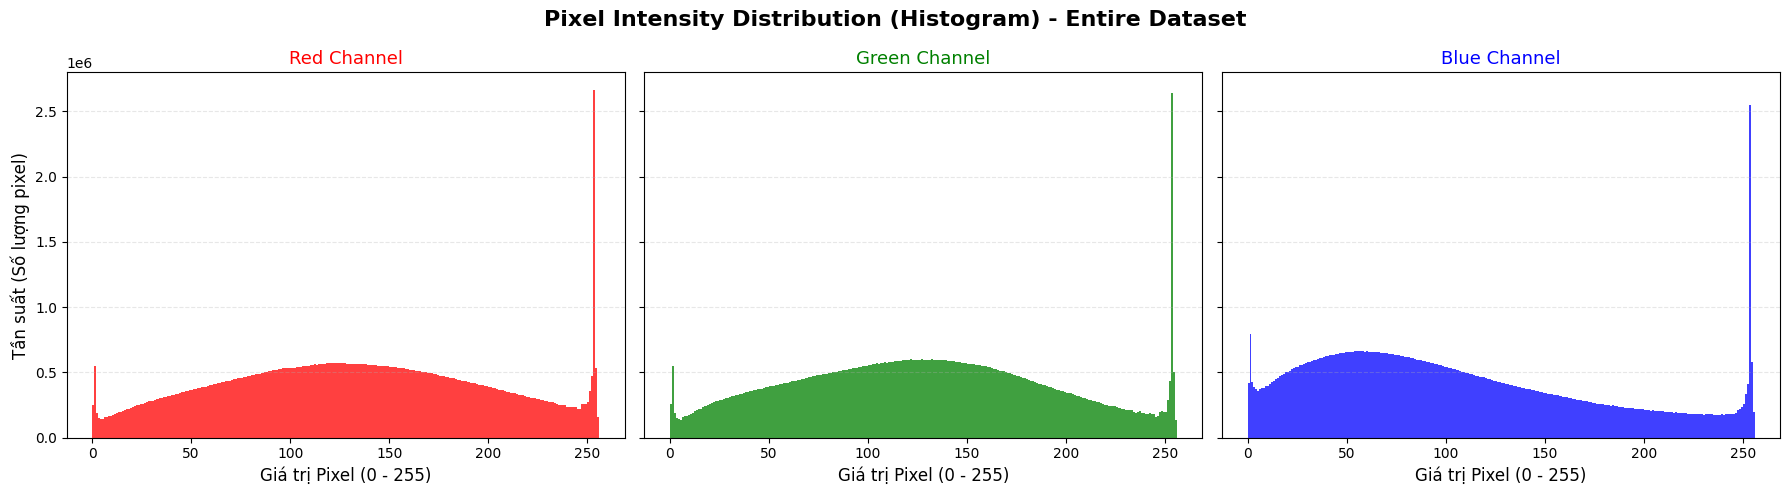

In [2]:
# Gọi hàm vẽ Histogram trên toàn bộ tập dữ liệu
print("\n--- PHÂN PHỐI HISTOGRAM TỔNG THỂ ---")
plot_histogram(pixel_data_all, title_suffix="- Entire Dataset")

# Đánh giá tổng quan phân phối Histogram trên toàn bộ Dataset

Dựa trên biểu đồ Histogram của 3 kênh màu (Red, Green, Blue) trên toàn tập dữ liệu `raw-img`, ta rút ra các nhận định chi tiết sau:

**1. Nhận xét dáng của biểu đồ:**
* Cả 3 kênh màu đều có phân phối phức tạp và **không tuân theo phân phối chuẩn**.
* **Kênh Red:** Có xu hướng **lệch phải**, mật độ pixel phân bố dày và trải dài ở dải giá trị từ 100 đến 200.
* **Kênh Green:** Phân bố khá rộng, hình dáng "vững chãi" và thoai thoải, tập trung nhiều ở dải trung tính (50 - 200).
* **Kênh Blue:** Biểu đồ **lệch trái** rõ rệt, tập trung một lượng lớn pixel ở dải giá trị thấp/tối (0 - 100).

**2. Nhận xét độ sáng của từng kênh màu:**
* **Kênh Red:** Việc lệch phải cho thấy kênh này sở hữu rất nhiều pixel ở vùng sáng. Suy ra tập ảnh chứa lượng lớn các sắc tố mang tông màu ấm (đỏ, cam, nâu).
* **Kênh Blue:** Đa số pixel dồn về dải tối, chứng tỏ hình ảnh thiếu hụt các nguồn sáng xanh dương tươi sáng (như bầu trời ngày nắng) hoặc các dải màu lạnh bị chìm vào vùng tối.

**3. So sánh giữa các kênh và xác định màu chủ đạo:**
* Tại vùng sáng (giá trị > 150), số lượng pixel của kênh **Red áp đảo hoàn toàn** so với Blue. Ngược lại, ở vùng tối (< 50), kênh Blue lại chiếm ưu thế về mật độ.
* **Kết luận:** Tập dữ liệu có sự mất cân bằng màu sắc tự nhiên. Màu chủ đạo nghiêng hẳn về **tông ấm (nhiều đỏ, vàng, nâu)**.

**4. Kiểm tra độ tương phản:**
* Biểu đồ trải rất rộng trên toàn bộ trục hoành từ 0 đến 255 mà không bị co cụm vào một khoảng hẹp. Điều này chứng tỏ tập dữ liệu có **độ tương phản tốt**, các chi tiết hình ảnh được phân bổ từ vùng tối sâu đến vùng sáng rõ.

**5. Kiểm tra hiện tượng Clip:**
* Tại giá trị cực đại **255**, xuất hiện các **cột vọt cao đột biến** ở cả 3 kênh.
* **Giải thích:** Đây là dấu hiệu của việc mất chi tiết vùng sáng (cháy sáng). Trong ngữ cảnh dataset này, nguyên nhân chủ yếu là do có nhiều hình ảnh sử dụng **nền trắng tinh** (R=G=B=255) để làm nổi bật chủ thể.


--- PHÂN PHỐI KDE TỔNG THỂ ---


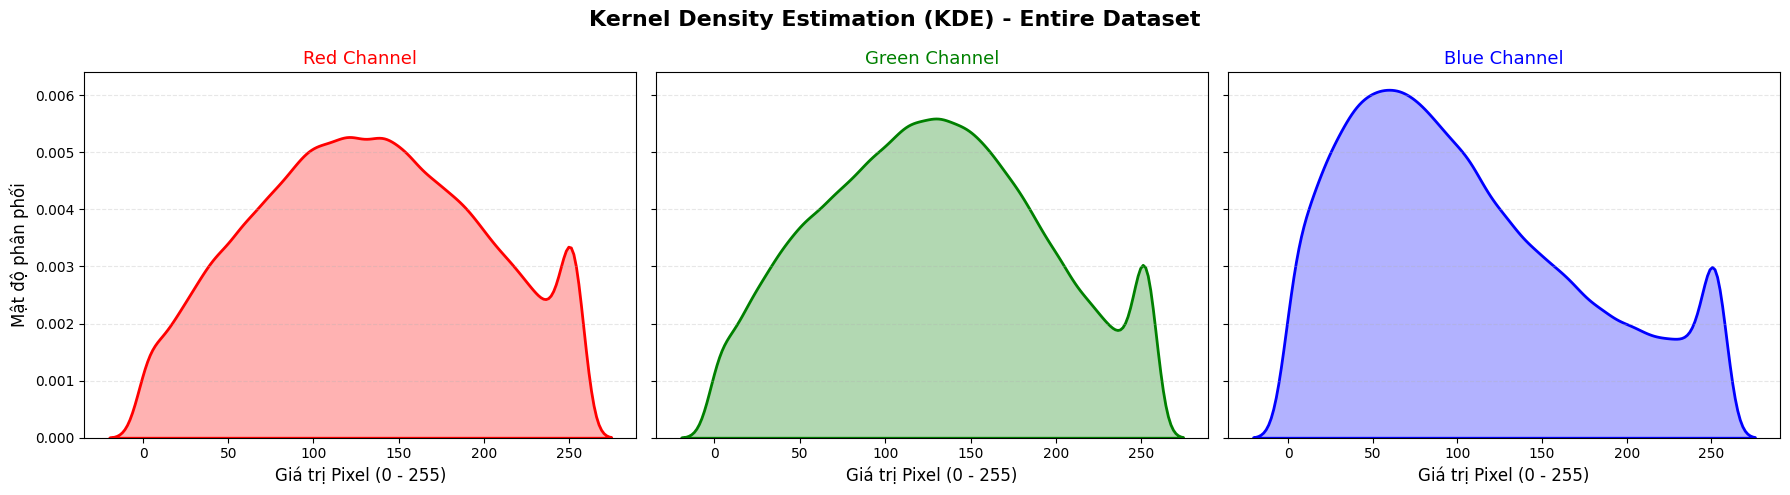

In [3]:
# Gọi hàm vẽ KDE trên toàn bộ tập dữ liệu
print("\n--- PHÂN PHỐI KDE TỔNG THỂ ---")
plot_kde(pixel_data_all, title_suffix="- Entire Dataset")

# Đánh giá tổng quan phân phối KDE trên toàn bộ Dataset

Biểu đồ Kernel Density Estimation (KDE) giúp quan sát mật độ điểm ảnh một cách liên tục và mượt mà hơn:

**1. Xác định đỉnh phân phối:**
* **Kênh Red:** Đỉnh tạo thành một dải rộng và cao nằm ở khu vực giá trị `[100 - 150]`, khẳng định ưu thế của sắc đỏ ở vùng trung tính và sáng.
* **Kênh Blue:** Đỉnh nhọn và cao vọt lên ở vùng giá trị `~50`, cho thấy mật độ pixel xanh dương tập trung cực lớn ở vùng tối.

**2. Xác định độ rộng của đường cong:**
* Đường cong KDE của cả 3 kênh đều rất rộng, bao phủ gần như trọn vẹn dải giá trị 0-255. Điều này tái khẳng định tập dữ liệu có **độ tương phản cao** và sự chuyển màu mượt mà.

**3. So sánh vị trí đỉnh và xu hướng màu:**
* Vị trí đỉnh của kênh Red nằm lệch hẳn về phía bên phải (vùng sáng) so với đỉnh của kênh Blue (vùng tối). Sự so le này xác nhận xu hướng ảnh thiên về các sắc tố tự nhiên mang tính ấm như da và lông động vật.

**4. Mức độ chồng lấp:**
* Các đường cong **không chồng lấp khít lên nhau**, đặc biệt khu vực đỉnh của kênh Red tách biệt rõ rệt so với kênh Blue. Sự thiếu đồng nhất này minh chứng cho tình trạng **mất cân bằng màu sắc** của tập dữ liệu gốc.


--- PHÂN PHỐI KDE THEO TỪNG CLASS ---


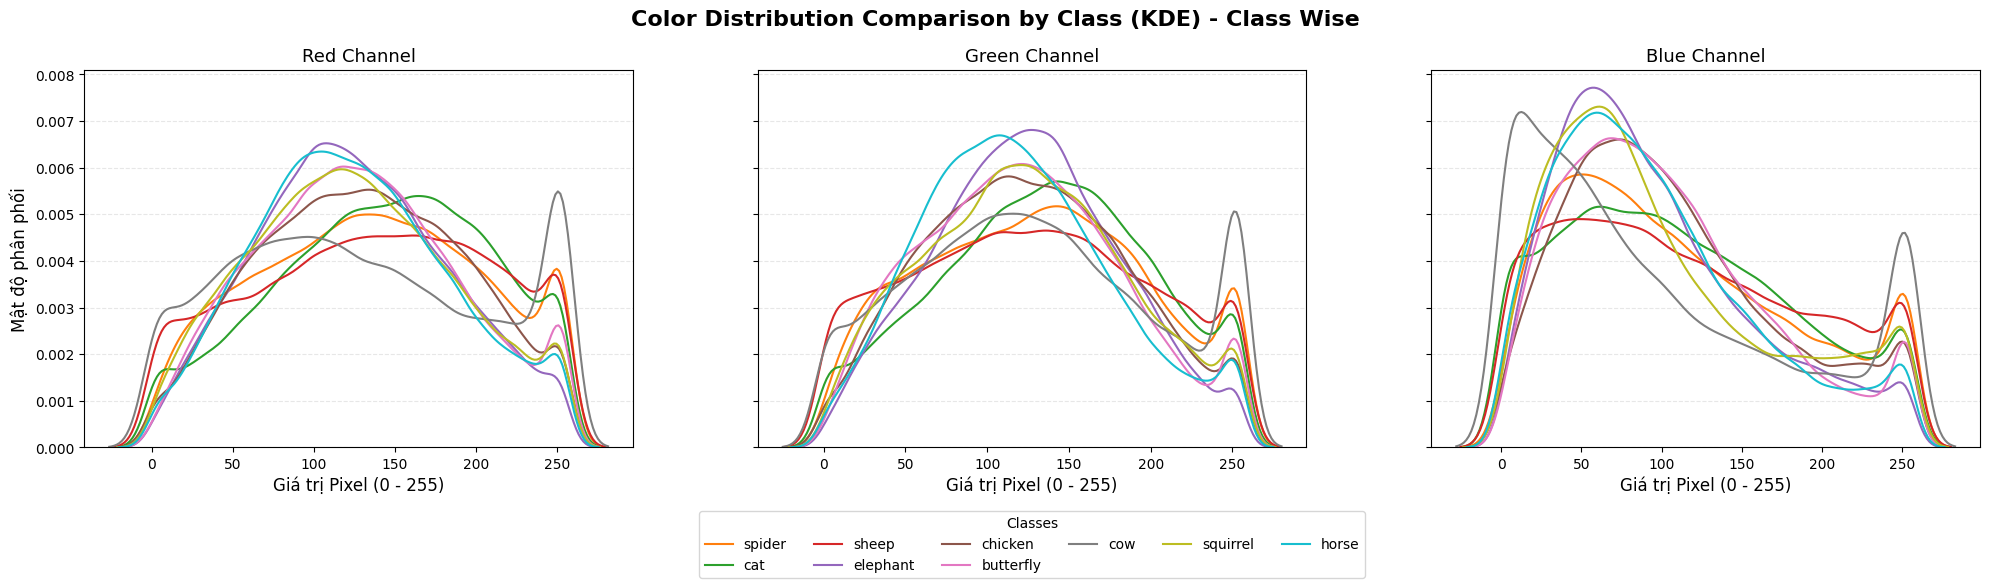

In [4]:
print("\n--- PHÂN PHỐI KDE THEO TỪNG CLASS ---")
plot_distribution_by_class(images, labels, class_names, title_suffix="- Class Wise")

# Đánh giá phân phối theo Class: Khám phá bản chất dữ liệu

Biểu đồ KDE phân rã theo từng Class là chìa khóa để giải mã các hiện tượng lạ ở biểu đồ tổng thể:

**1. Giải thích sự phân bố tổng quan bằng phân phối cục bộ:**
* **Tại sao kênh Red tổng thể bị lệch phải?** Nhìn vào KDE Class-wise (Red Channel), ta thấy các lớp như `sheep`, `cat`, `cow`, `horse` có đường cong nhô cao ở dải sáng. Chính sắc tố lông tự nhiên của các nhóm loài này đã "kéo" phân phối tổng thể của kênh Red về phía bên phải.
* **Tại sao kênh Blue tổng thể bị lệch trái?**
  Lớp `butterfly` (xanh dương đậm) và một số lớp động vật rừng có đỉnh vọt lên rất cao ở vùng giá trị thấp (`~30`). Những pixel "xanh tối" này là nguyên nhân chính tạo nên đỉnh nhọn ở vùng tối của kênh Blue trong biểu đồ tổng.
* **Nguồn gốc của cột cháy sáng 255:**
  Ở sát mốc giá trị 250-255, các lớp `butterfly` và `dog` đồng loạt xuất hiện các đỉnh phụ. Điều này chứng minh rằng các ảnh thuộc lớp này thường xuyên được chụp trên **phông nền trắng nhân tạo**, tạo ra hiện tượng Clip trên biểu đồ tổng.

**2. Kết luận: Histogram toàn bộ Dataset có phản ánh đúng bản chất không?**
* **Câu trả lời là KHÔNG HOÀN TOÀN.** Histogram tổng thể chỉ là một "bức tranh trung bình" bị chi phối bởi các lớp có đặc điểm màu sắc cực đoan. 
* Nếu chỉ dựa vào biểu đồ tổng để kết luận *"Dataset bị dư màu đỏ"* là sai lầm, vì sắc đỏ đó là **đặc trưng sinh học** của các lớp như mèo hay cừu. Việc giảm kênh Red trên toàn tập dữ liệu sẽ làm hỏng tính xác thực của các lớp này.
* **Định hướng tiền xử lý:** Mọi quyết định về chuẩn hóa hay cân bằng màu sắc **bắt buộc phải được kiểm tra ở mức độ từng lớp** để bảo toàn các đặc trưng quan trọng giúp mô hình học máy phân loại chính xác.